LangGraph

### Агент: активность на GitHub

Собирает активность за последний месяц по пользователю о гитхабе (чтобы оценить, что сделал или не сделал).

### Как работает:

Агент LangGraph со следующими состояниями:

start -> fetch_github -> analyze -> end

In [ ]:
OPENROUTER_TOKEN = ""

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model="openrouter/free"
)

print(llm.invoke("Привет! Ответь одним словом.").content)

Привет!



In [5]:
from typing import TypedDict, List
from langgraph.graph import START, END, StateGraph

class GitHubState(TypedDict):
    username: str
    user_events: list
    answer: str

In [ ]:
import requests
from datetime import datetime, timezone, timedelta


def fetch_github_activity(state: GitHubState) -> dict:
    username = state["username"]
    url = f"https://api.github.com/users/{username}/events/public"
    response = requests.get(url, headers={"Accept": "application/vnd.github.v3+json"})
    if response.status_code != 200:
        print(f"Ошибка Github API: {response.status_code}")
        return {"user_events": []}
    events = response.json()
    month_ago = datetime.now(timezone.utc) - timedelta(days=30)
    event_types = {"PushEvent", "PullRequestEvent", "CreateEvent", "IssuesEvent"}
    result = []

    for event in events:
        created_at = datetime.fromisoformat(event["created_at"].replace("Z", "+00:00"))
        if created_at < month_ago:
            continue
        if event["type"] not in event_types:
            continue

        entry = {
            "type": event["type"],
            "repo": event["repo"]["name"],
            "date": created_at.strftime("%Y-%m-%d"),
        }
        result.append(entry)

    return {"user_events": result}

In [7]:
def analyze_activity(state: GitHubState) -> dict:
    username = state["username"]
    events = state["user_events"]

    if not events:
        return {"answer": f"За последний месяц у {username} не найдено активности на GitHub."}

    activity = ""
    for e in events:
        line = f"{e['date']} {e['type']} в {e['repo']}"
        activity += line + "\n"

    prompt = f"""Ты — помошник разработчика. Проанализируй активность {username} на GitHub за последний месяц и составь краткий отчёт.
Активность:  {activity}

Напиши отчёт в следующем формате:
насколько активным был месяц, сколько событий,
над какими репозиториями шла работа
вывод.

Пиши кратко и по делу."""
    result = llm.invoke(prompt).content
    return {"answer": result}

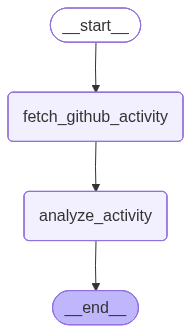

In [8]:
graph_builder = StateGraph(GitHubState)

graph_builder.add_node("fetch_github_activity", fetch_github_activity)
graph_builder.add_node("analyze_activity", analyze_activity)
graph_builder.add_edge(START, "fetch_github_activity")
graph_builder.add_edge("fetch_github_activity", "analyze_activity")
graph_builder.add_edge("analyze_activity", END)
graph = graph_builder.compile()
graph

In [9]:
result = graph.invoke({"username": "toxabrat"})

print(result["answer"])

Как активно работает toxabrat на GitHub в последнем месяце — **поддерживательный**.  
Работा: 5 события ( Push/Create), 1 отдельное репозиториев, активное общение.  
Вывод: активность средняя, стимулятивна для коллейки.


In [10]:
for event in result["user_events"][:5]:
    print(event)

{'type': 'PushEvent', 'repo': 'toxabrat/sovmestno-front', 'date': '2026-03-27'}
{'type': 'PullRequestEvent', 'repo': 'toxabrat/sovmestno-front', 'date': '2026-03-20'}
{'type': 'PullRequestEvent', 'repo': 'toxabrat/sovmestno-front', 'date': '2026-03-20'}
{'type': 'CreateEvent', 'repo': 'toxabrat/sovmestno-front', 'date': '2026-03-20'}
{'type': 'PushEvent', 'repo': 'toxabrat/sovmestno-front', 'date': '2026-03-19'}
